Načteno snímků skupiny A: 5
Načteno snímků skupiny B: 5


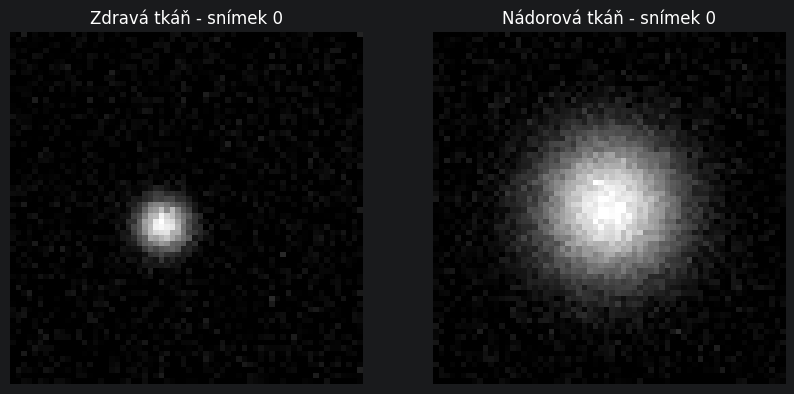

In [1]:
%matplotlib inline
import glob
import numpy as np
import matplotlib.pyplot as plt

files_a = sorted(glob.glob("skupina_a/*.png"))
files_b = sorted(glob.glob("skupina_b/*.png"))

skupina_a = [plt.imread(cesta)[:, :, 0] for cesta in files_a]
skupina_b = [plt.imread(cesta)[:, :, 0] for cesta in files_b]

print(f"Načteno snímků skupiny A: {len(skupina_a)}")
print(f"Načteno snímků skupiny B: {len(skupina_b)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(skupina_a[0], cmap="gray", vmin=0, vmax=1)
ax1.set_title("Zdravá tkáň - snímek 0")
ax1.axis("off")

ax2.imshow(skupina_b[0], cmap="gray", vmin=0, vmax=1)
ax2.set_title("Nádorová tkáň - snímek 0")
ax2.axis("off")

plt.show()

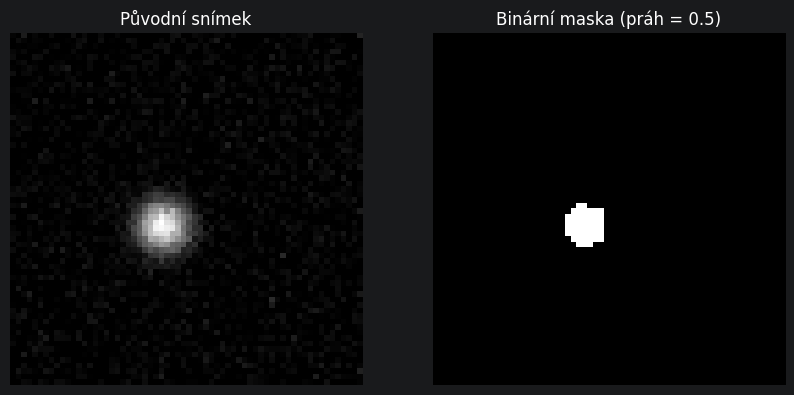

In [2]:
PRAH = 0.5
snimek = skupina_a[0]

maska = snimek > PRAH

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(snimek, cmap="gray", vmin=0, vmax=1)
ax1.set_title("Původní snímek")
ax1.axis("off")

ax2.imshow(maska, cmap="gray")
ax2.set_title(f"Binární maska (práh = {PRAH})")
ax2.axis("off")

plt.show()

In [3]:
podil = (maska.sum() / maska.size) * 100

mean_int = snimek[maska].mean()

print(f"Plocha struktury: {podil:.1f} %")
print(f"Průměrná intenzita: {mean_int:.3f}")

Plocha struktury: 1.1 %
Průměrná intenzita: 0.714


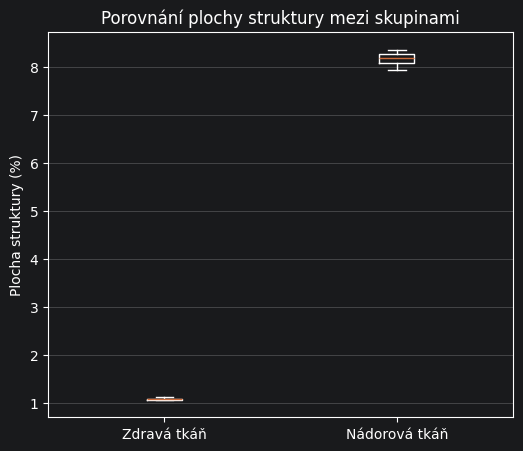

Skupina A (zdravá tkáň): ['1.1 %', '1.1 %', '1.1 %', '1.1 %', '1.1 %']
Skupina B (nádorová tkáň): ['8.1 %', '8.3 %', '8.3 %', '7.9 %', '8.2 %']


In [4]:
PRAH = 0.5

def spocitej_podil(snimek, prah):
    maska = snimek > prah
    return (maska.sum() / maska.size) * 100

podily_a = [spocitej_podil(img, PRAH) for img in skupina_a]
podily_b = [spocitej_podil(img, PRAH) for img in skupina_b]

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot([podily_a, podily_b], tick_labels=["Zdravá tkáň", "Nádorová tkáň"])
ax.set_title("Porovnání plochy struktury mezi skupinami")
ax.set_ylabel("Plocha struktury (%)")
ax.grid(True, axis="y", alpha=0.4)
plt.show()

print("Skupina A (zdravá tkáň):", [f"{p:.1f} %" for p in podily_a])
print("Skupina B (nádorová tkáň):", [f"{p:.1f} %" for p in podily_b])